In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [2]:
df.head()         

,Temperature,Fuel_Price,Holiday,Sales
Date,,,,
2020-01-01,28.1,2.71,1,6997
2020-01-02,25.1,2.64,0,4463
2020-01-03,29.1,2.51,0,5176
2020-01-04,33.6,2.41,0,6628
2020-01-05,25.0,2.61,0,5659


In [3]:
print(df.shape,"\n")          
print(df.isnull().sum()) 

(1000, 4) 

Temperature    0
Fuel_Price     0
Holiday        0
Sales          0
dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1000 entries, 2020-01-01 to 2022-09-26
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  1000 non-null   float64
 1   Fuel_Price   1000 non-null   float64
 2   Holiday      1000 non-null   int64  
 3   Sales        1000 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 39.1 KB


In [5]:
df.describe()

,Temperature,Fuel_Price,Holiday,Sales
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,57.146400,3.360710,0.015000,9711.352000
std,21.647032,0.509766,0.121613,2553.548018
min,15.100000,2.180000,0.000000,4003.000000
25%,37.575000,2.930000,0.000000,7742.750000
50%,59.100000,3.360000,0.000000,9716.000000
75%,77.025000,3.780000,0.000000,11680.500000
max,98.300000,4.600000,1.000000,19161.000000


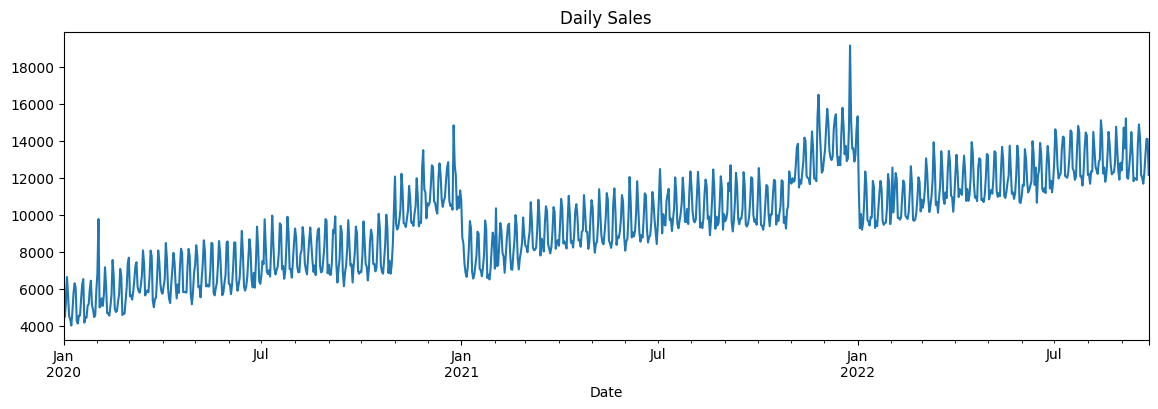

In [6]:
df['Sales'].plot(figsize=(14, 4), title='Daily Sales')
plt.show()

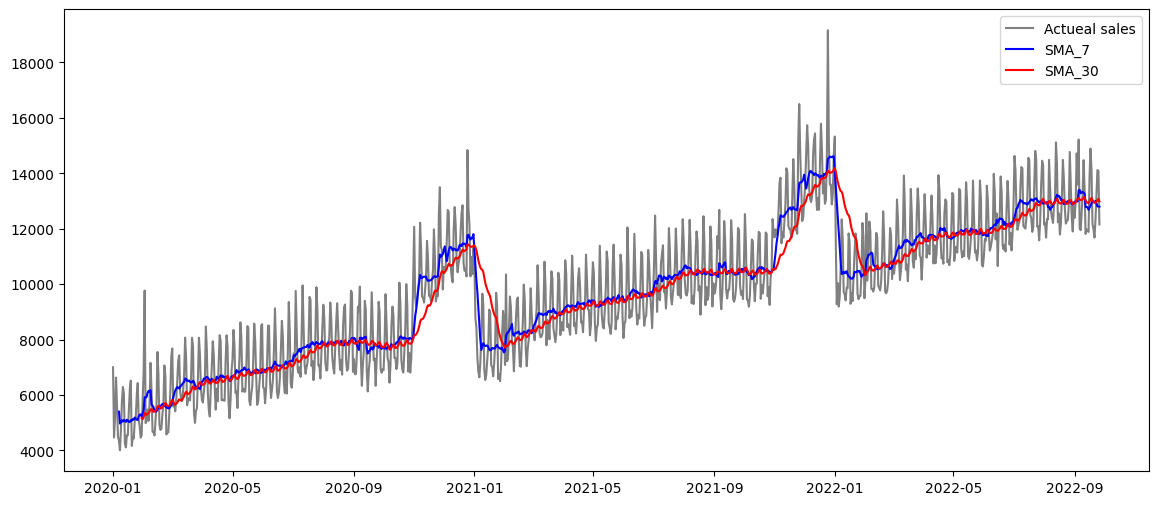

In [7]:
df['SMA_7'] = df["Sales"].rolling(window=7).mean()
df['SMA_30'] = df["Sales"].rolling(window=30).mean()

plt.figure(figsize=(14,6))
plt.plot(df["Sales"], label = "Actueal sales", color="grey")
plt.plot(df["SMA_7"], label = "SMA_7", color="blue")
plt.plot(df["SMA_30"], label = "SMA_30", color="red")
plt.legend()
plt.show()

df.drop("SMA_7", axis=1, inplace=True)
df.drop("SMA_30", axis=1, inplace=True)

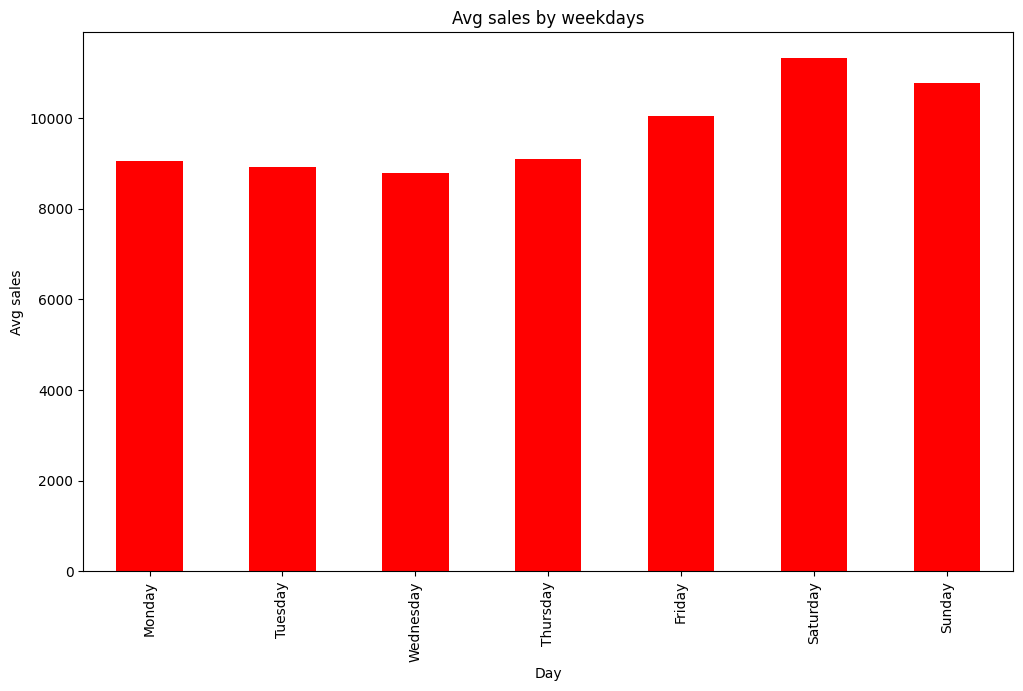

In [8]:
df["weekday"] = df.index.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

weekday_avg = df.groupby("weekday")["Sales"].mean()
weekday_avg = weekday_avg.reindex(weekday_order)

plt.figure(figsize=(12,7))
weekday_avg.plot(kind="bar", color="red")
plt.title("Avg sales by weekdays")
plt.xlabel("Day")
plt.ylabel("Avg sales")
plt.show()

df.drop("weekday", axis=1, inplace=True)

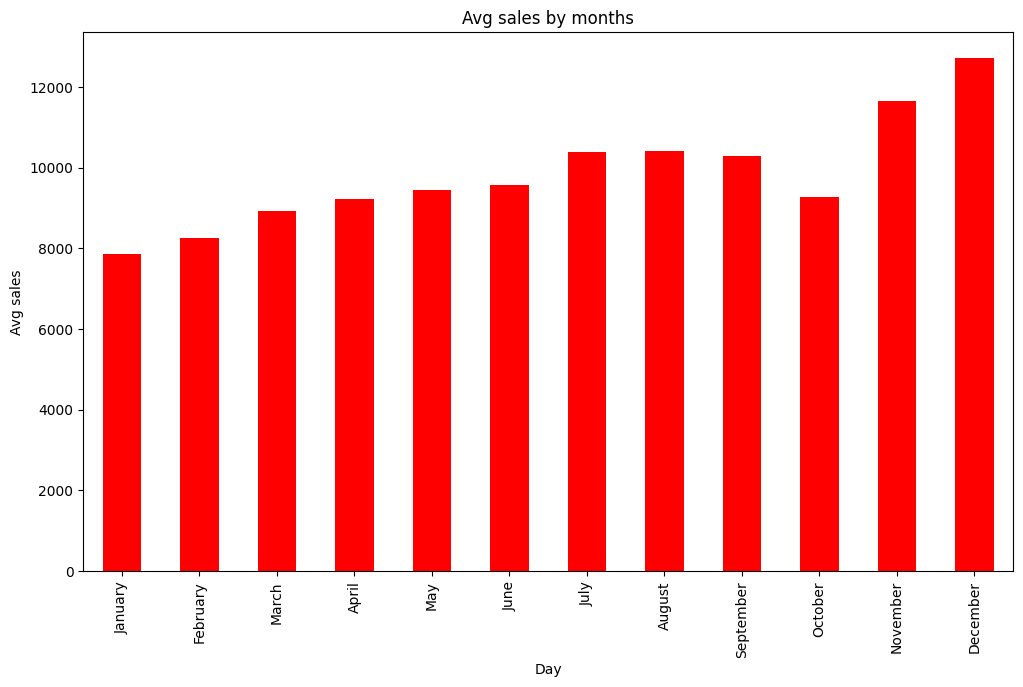

In [9]:
df["month"] = df.index.month_name()
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

month_avg = df.groupby("month")["Sales"].mean()
month_avg = month_avg.reindex(month_order)

plt.figure(figsize=(12,7))
month_avg.plot(kind="bar", color="red")
plt.title("Avg sales by months")
plt.xlabel("Day")
plt.ylabel("Avg sales")
plt.show()

df.drop("month", axis=1, inplace=True)

In [10]:
print(df.groupby('Holiday')['Sales'].mean())

Holiday
0     9660.874112
1    13026.066667
Name: Sales, dtype: float64


In [11]:
df['lag_1'] = df['Sales'].shift(1)
df['lag_7'] = df['Sales'].shift(7)
df['lag_30'] = df['Sales'].shift(30)

In [12]:
df['rolling_7_mean'] = df['Sales'].shift(1).rolling(7).mean()
df['rolling_7_std'] = df['Sales'].shift(1).rolling(7).std()

df['rolling_14_mean'] = df['Sales'].shift(1).rolling(14).mean()
df['rolling_14_std'] = df['Sales'].shift(1).rolling(14).std()

df['rolling_30_mean'] = df['Sales'].shift(1).rolling(30).mean()
df['rolling_30_std'] = df['Sales'].shift(1).rolling(30).std()

In [13]:
df['day_of_month'] = df.index.day

df["day_of_week"] = df.index.dayofweek
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df["month"] = df.index.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df["quarter"] = df.index.quarter
df['quarter_sin'] = np.sin(2 * np.pi * df['quarter'] / 4)
df['quarter_cos'] = np.cos(2 * np.pi * df['quarter'] / 4)

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [14]:
df['expanding_sum'] = df['Sales'].expanding().sum()
df['expanding_mean'] = df['Sales'].expanding().mean()
df['expanding_std'] = df['Sales'].expanding().std()

In [15]:
print(f"Total features created: {len(df.columns)}") 
print("\nFeature columns:")
print(df.columns.tolist())

Total features created: 27

Feature columns:
['Temperature', 'Fuel_Price', 'Holiday', 'Sales', 'lag_1', 'lag_7', 'lag_30', 'rolling_7_mean', 'rolling_7_std', 'rolling_14_mean', 'rolling_14_std', 'rolling_30_mean', 'rolling_30_std', 'day_of_month', 'day_of_week', 'day_sin', 'day_cos', 'month', 'month_sin', 'month_cos', 'quarter', 'quarter_sin', 'quarter_cos', 'is_weekend', 'expanding_sum', 'expanding_mean', 'expanding_std']


In [16]:
df.head(35)

,Temperature,Fuel_Price,Holiday,Sales,lag_1,lag_7,lag_30,rolling_7_mean,rolling_7_std,rolling_14_mean,...,month,month_sin,month_cos,quarter,quarter_sin,quarter_cos,is_weekend,expanding_sum,expanding_mean,expanding_std
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,28.1,2.71,1,6997,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0.500000,0.866025,1,1.0,6.123234e-17,0,6997.0,6997.000000,NaN
2020-01-02,25.1,2.64,0,4463,6997.0,NaN,NaN,NaN,NaN,NaN,...,1,0.500000,0.866025,1,1.0,6.123234e-17,0,11460.0,5730.000000,1791.808584
2020-01-03,29.1,2.51,0,5176,4463.0,NaN,NaN,NaN,NaN,NaN,...,1,0.500000,0.866025,1,1.0,6.123234e-17,0,16636.0,5545.333333,1306.749530
2020-01-04,33.6,2.41,0,6628,5176.0,NaN,NaN,NaN,NaN,NaN,...,1,0.500000,0.866025,1,1.0,6.123234e-17,1,23264.0,5816.000000,1196.427181
2020-01-05,25.0,2.61,0,5659,6628.0,NaN,NaN,NaN,NaN,NaN,...,1,0.500000,0.866025,1,1.0,6.123234e-17,1,28923.0,5784.600000,1038.512542
2020-01-06,25.1,2.57,0,4499,5659.0,NaN,NaN,NaN,NaN,NaN,...,1,0.500000,0.866025,1,1.0,6.123234e-17,0,33422.0,5570.333333,1066.896371
2020-01-07,34.4,2.64,0,4342,4499.0,NaN,NaN,NaN,NaN,NaN,...,1,0.500000,0.866025,1,1.0,6.123234e-17,0,37764.0,5394.857143,1078.934571
2020-01-08,30.5,2.61,0,4003,4342.0,6997.0,NaN,5394.857143,1078.934571,NaN,...,1,0.500000,0.866025,1,1.0,6.123234e-17,0,41767.0,5220.875000,1113.534070
2020-01-09,24.5,2.67,0,4753,4003.0,4463.0,NaN,4967.142857,919.640043,NaN,...,1,0.500000,0.866025,1,1.0,6.123234e-17,0,46520.0,5168.888889,1053.226643


In [17]:
nan_count = df.isnull().sum()
print(nan_count[nan_count > 0])

lag_1               1
lag_7               7
lag_30             30
rolling_7_mean      7
rolling_7_std       7
rolling_14_mean    14
rolling_14_std     14
rolling_30_mean    30
rolling_30_std     30
expanding_std       1
dtype: int64


In [18]:
df_clean = df.dropna()

print(f"\nOriginal rows : {len(df)}")
print(f"After dropna  : {len(df_clean)}")
print(f"Rows removed  : {len(df) - len(df_clean)}")
print(f"Data loss %   : {((len(df) - len(df_clean)) / len(df)) * 100:.1f}%")


Original rows : 1000
After dropna  : 970
Rows removed  : 30
Data loss %   : 3.0%


In [19]:
corr = df_clean.corr(numeric_only=True)
corr['Sales'].sort_values(ascending=False)

Sales              1.000000
lag_7              0.943192
lag_1              0.894924
rolling_7_mean     0.892029
rolling_14_mean    0.883033
rolling_30_mean    0.862391
expanding_mean     0.819473
expanding_sum      0.805185
expanding_std      0.795705
Fuel_Price         0.776654
lag_30             0.673109
month              0.378038
quarter            0.359846
is_weekend         0.343469
day_of_week        0.328792
quarter_cos        0.228632
Holiday            0.177597
month_cos          0.099869
rolling_7_std      0.044023
rolling_14_std     0.021404
rolling_30_std     0.016419
day_of_month       0.010562
day_cos           -0.038057
Temperature       -0.078768
quarter_sin       -0.235396
month_sin         -0.248220
day_sin           -0.357017
Name: Sales, dtype: float64

In [20]:
# 80% train, 20% test
split = int(len(df) * 0.8)

train = df.iloc[:split]
test  = df.iloc[split:]

print(f"Train: {train.index[0].date()} to {train.index[-1].date()}")
print(f"Test:  {test.index[0].date()} to {test.index[-1].date()}")
print(f"Train rows: {len(train)}, Test rows: {len(test)}")

Train: 2020-01-01 to 2022-03-10
Test:  2022-03-11 to 2022-09-26
Train rows: 800, Test rows: 200


In [21]:
features = [
    'lag_1', 'lag_7', 'lag_30',
    'rolling_7_mean', 'rolling_14_mean', 'rolling_30_mean',
    'Fuel_Price',
    'day_of_week', 'month', 'quarter', 'is_weekend', 'Holiday'
]

X_train = train[features]
y_train = train['Sales']

X_test = test[features]
y_test = test['Sales']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (800, 12)
X_test shape:  (200, 12)


In [22]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,   # 100 trees
    random_state=42     # reproducible results
)

model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [23]:
y_pred = model.predict(X_test)

result = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred.astype(int)
})
result['Difference'] = result['Actual'] - result['Predicted']
print(result.head(10))

   Actual  Predicted  Difference
0   11860      11705         155
1   13920      12220        1700
2   12724      12648          76
3   10525      10981        -456
4   10704      10725         -21
5   10107      10638        -531
6   10923      10726         197
7   11604      11794        -190
8   13436      12447         989
9   12503      12352         151


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
accuracy = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.0f}")   
print(f"RMSE : {rmse:.0f}")   
print(f"MAPE : {mape:.2f}%") 
print("R2  :", accuracy)

MAE  : 480
RMSE : 625
MAPE : 3.84%
R2  : 0.7120186409394542


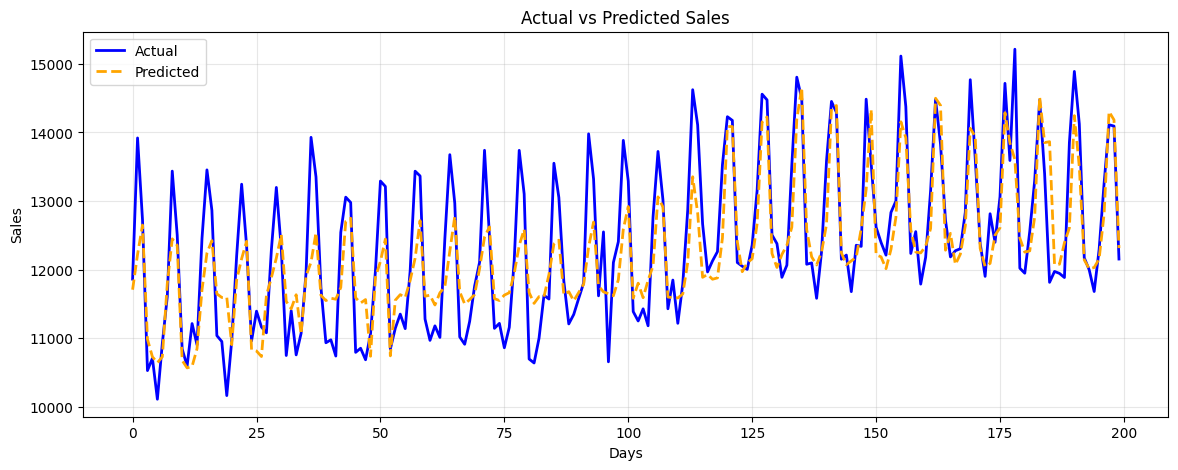

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Actual', linewidth=2, color='blue')
plt.plot(y_pred,   label='Predicted', linewidth=2, 
         color='orange', linestyle='--')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Days')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

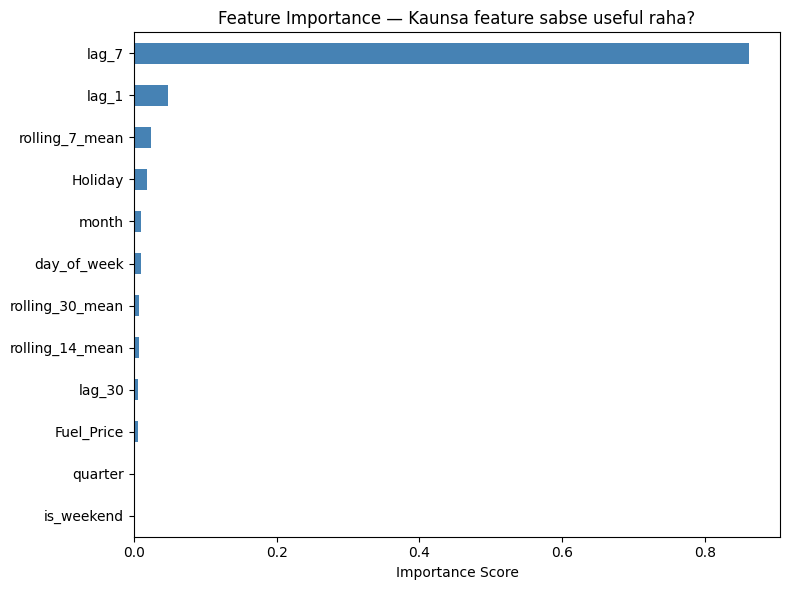

lag_7              0.862271
lag_1              0.047615
rolling_7_mean     0.024558
Holiday            0.017808
month              0.010320
day_of_week        0.009828
rolling_30_mean    0.006880
rolling_14_mean    0.006402
lag_30             0.006268
Fuel_Price         0.005905
quarter            0.001208
is_weekend         0.000936
dtype: float64


In [26]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

importance.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Feature Importance — Kaunsa feature sabse useful raha?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False))